In [1]:
import numpy as np
import networkx as nx
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt
import torch
import pandas as pd
from sklearn.decomposition import PCA
from node2vec import Node2Vec
from torch.distributions import Laplace, Normal
import torch.optim as optim
from sklearn.mixture import GaussianMixture


# DP algorithms

In [2]:
def random_projection(A, m , epsilon, delta):
    """
    Algorithm 1 from: https://arxiv.org/pdf/1307.0475
    """

    n = A.shape[0]
    variance = 1/epsilon * np.sqrt(10*(epsilon + np.log(1/(2*delta)))*np.log(n/delta))
    P = np.random.normal(0, 1/np.sqrt(m), size=(A.shape[0], m))
    Q = np.random.normal(0, np.sqrt(variance), size=(A.shape[0], m) )

    return A @ P + Q


In [3]:
def edge_randomization(A, epsilon):
    """
    Algorithm 3 from: https://arxiv.org/pdf/2108.06504
    or 
    Algorithm 1 from: https://ceur-ws.org/Vol-1330/paper-39.pdf
    """

    # Convert epsilon to s
    if epsilon < np.log(2):
        raise Exception("Epsilon value is too small, need to be at least ln(2)")
    
    s = 2/np.exp(epsilon)

    # Create A_perturbed
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            x = np.random.binomial(n=1, p=1-s)
            if x == 1:
                A_perturbed[i,j] = A[i,j]
                A_perturbed[j,i] = A[i,j]
            else:
                y = np.random.binomial(n=1, p=0.5)
                A_perturbed[i,j] = y
                A_perturbed[j,i] = y

    return A_perturbed


In [4]:
def lapgraph(A, epsilon):
    """
    Algorithm 4 from: https://arxiv.org/pdf/2108.06504
    """

    # Distribute privacy budget to 2 steps: 
    # + Adding Laplace noise to the A matrix
    # + Keeping the top cells within the perturbed matrix

    epsilon_1 = 0.01*epsilon
    epsilon_2 = epsilon - epsilon_1

    # Get DP edge count
    T = int(np.sum(A)/2 + np.random.laplace(scale=1/epsilon_1)) # Laplace noise may not be suitable for count statistics

    # Get A_perturbed with Laplace noise
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            A_perturbed[i,j] = A[i,j] + np.random.laplace(scale=1/epsilon_2)

    # Get the indices of the top T cells
    top_indices = np.unravel_index(np.argpartition(A_perturbed.flatten(), -T)[-T:], A.shape)

    # Reset all cells to 0 and set only cells in top_indices to 1
    A_perturbed = np.zeros(A.shape)
    A_perturbed[top_indices] = 1
    
    return A_perturbed + A_perturbed.T

In [5]:
def edge_flip(A, epsilon):
    """
    Definition 5 from: https://arxiv.org/pdf/2105.12615
    """
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))
            if x == 1:
                A_perturbed[i,j] = 1 - A[i,j]
                A_perturbed[j,i] = 1 - A[i,j]
            else:
                A_perturbed[i,j] = A[i,j]
                A_perturbed[j,i] = A[i,j]
    
    return A_perturbed

In [6]:
def deepwalk_laplace_svd(A, embedding_dim, walk_length, epsilon, take_log=False):
    """
    DP DeepWalk with laplace noise and factorization by SVD
    """

    D_inversed = torch.diag(torch.sum(torch.tensor(A), dim=1)**-1)
    
    Z = torch.zeros(A.shape).double()
    power_matrix = torch.eye(A.shape[0]).double()
    base_matrix = D_inversed @ A
    for _ in range(walk_length):
        power_matrix = power_matrix @ base_matrix
        Z += power_matrix

    Z = Z/walk_length

    # Add laplace noise to Z
    Z = Z + torch.distributions.Laplace(loc=0, scale=np.sqrt(2)/epsilon).sample(sample_shape=Z.shape)

    if take_log:
        Z = torch.log(Z)
    
    # Use SVD to factorize
    U, S, _ = torch.linalg.svd(Z, full_matrices=False)

    X = U[:, :embedding_dim] @ torch.sqrt(torch.diag(S[:embedding_dim]))
    return X

In [77]:
def deepwalk_dp(A, H, k, walk_length, epsilon, lambda_reg=0.1, learning_rate=0.01, num_epochs=1000, verbose=False):
    
    sensitivity = np.sqrt(2)
    normal_dist = Normal(loc=0, scale=1)
    laplace_dist = Laplace(loc=0.0, scale=2*sensitivity/epsilon)

    D_inversed = np.diag(np.sum(A, axis=1)**-1)
    P = D_inversed@A

    power_matrix = np.eye(A.shape[0])
    sum_matrix = np.zeros(A.shape)
    for _ in range(walk_length):
        power_matrix = power_matrix @ P
        sum_matrix += power_matrix

    M = sum_matrix/walk_length
    M = torch.tensor(M, requires_grad=False)
    H = torch.tensor(H, requires_grad=False)
    W = normal_dist.sample((A.shape[0], k)).requires_grad_(True)
    N = laplace_dist.sample(W.shape).requires_grad_(False)
    mask = torch.triu(torch.ones(M.shape), diagonal=1).requires_grad_(False)

    optimizer = optim.SGD([W], lr=learning_rate, momentum=0.9)

    for epoch in range(num_epochs):
        # Forward pass
        private_loss = torch.sum(((M - W@H.T)*mask)**2) + lambda_reg*torch.sum(W**2) + torch.trace(W@N.T)

        # Backward pass
        optimizer.zero_grad()  # Clear gradients
        private_loss.backward()        # Compute gradients
        optimizer.step()       # Update weights
        
        if epoch % 100 == 0 and verbose:
            print(f'Epoch {epoch}, Loss: {private_loss.item():.25f}')
    
    return W

def deepwalk_get_H(G, k, seed=0, window=5):
    node2vec = Node2Vec(G, dimensions=k, walk_length=100, num_walks=10, workers=1, seed=seed)
    model = node2vec.fit(window=window, min_count=0, seed=seed, sg=1, negative=5, epochs=1, ns_exponent=1)

    emb_X = []
    for node_name in G.nodes():
        emb_X.append(model.wv[str(node_name)])
    H = np.vstack(emb_X)
    H = H / np.linalg.norm(H, ord=2, axis=1, keepdims=True)

    return H

# Manually fit Objective Perturbed DeepWalk

In [86]:
epsilon_values

array([1.00000000e-01, 2.31012970e-01, 5.33669923e-01, 1.23284674e+00,
       2.84803587e+00, 6.57933225e+00, 1.51991108e+01, 3.51119173e+01,
       8.11130831e+01, 1.87381742e+02, 4.32876128e+02, 1.00000000e+03])

In [87]:
torch.manual_seed(0)
np.random.seed(0)

deepwalk_dimension=64

H_np = deepwalk_get_H(G, deepwalk_dimension)

Computing transition probabilities:   0%|          | 0/1222 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:08<00:00,  1.15it/s]


In [134]:
seed = 1
for seed in range(1):

    torch.manual_seed(seed)
    W = deepwalk_dp(A, H_np, deepwalk_dimension, walk_length=5, epsilon=6.57933225e+00, lambda_reg=1480.35889, learning_rate=0.0001, num_epochs=301, verbose=True)
    kmeans = KMeans(n_clusters=2, n_init=100, random_state=seed)
    embeddings = W.detach().numpy()
    cluster_labels = kmeans.fit_predict(embeddings)

    nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
    print('DeepWalk NMI Score: {}'.format(nmi_score))

Epoch 0, Loss: 116541816.3883891701698303222656250
Epoch 100, Loss: 3113.9572818009978618647437543
Epoch 200, Loss: 5.0149496817576260099258434
Epoch 300, Loss: 4.9342952816076532940314792
DeepWalk NMI Score: 9.461158291972431e-05


DeepWalk NMI Score: 0.6847736219060268


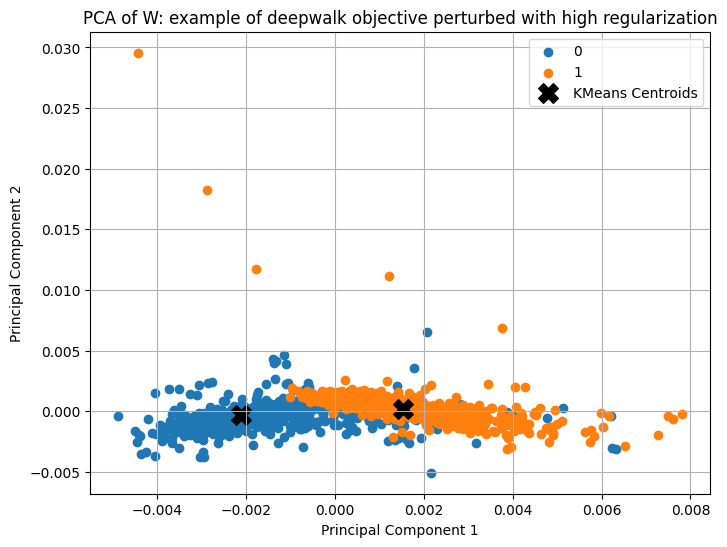

KMeans labels: [0 0 1 ... 1 1 1]


In [104]:
## Perform PCA on W
pca = PCA()

embeddings = W.detach().numpy()
W_pca = pca.fit_transform(embeddings)


## Combine with class labels
pca_df = pd.DataFrame({
    'PC1': W_pca[:, 0],
    'PC2': W_pca[:, 1],
    'label': true_labels
})

# print("Explained variance ratio:", pca.explained_variance_ratio_)

# Plot the first two principal components
plt.figure(figsize=(8, 6))

for label in np.unique(pca_df['label']):
    # if label == 0:
    #     continue
    indices = pca_df['label'] == label
    plt.scatter(pca_df.loc[indices, 'PC1'], pca_df.loc[indices, 'PC2'], label=label)
# plt.scatter(pca_df.loc[:, 'PC1'], pca_df.loc[:, 'PC2'])

plt.title('PCA of W: example of deepwalk objective perturbed with high regularization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)

kmeans = KMeans(n_clusters=2, n_init=100, random_state=seed)
cluster_labels = kmeans.fit_predict(embeddings)

nmi_score = normalized_mutual_info_score(pca_df['label'], cluster_labels)
print('DeepWalk NMI Score: {}'.format(nmi_score))

# Plot the centroids for each KMeans cluster on the same plot
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=200, label='KMeans Centroids')
plt.legend()
plt.show()

print('KMeans labels: {}'.format(kmeans.labels_))

# Experiments

## SBM

In [44]:
np.random.seed(0)
sizes = [100, 100, 100]
probs = [
    [0.8, 0.4, 0.4],
    [0.4, 0.8, 0.4],
    [0.4, 0.4, 0.8],
]

# Generate the SBM graph
G = nx.stochastic_block_model(sizes, probs, seed=0)
A = nx.to_numpy_array(G)

# Get the true labels from the SBM
true_labels = []
for i, size in enumerate(sizes):
    true_labels.extend([i] * size)

In [9]:
torch.manual_seed(0)
np.random.seed(0)

deepwalk_dimension=64
# H_np = deepwalk_get_H(G, deepwalk_dimension)

In [10]:
torch.manual_seed(0)
np.random.seed(0)

# Define epsilon values to test
# epsilon_values = np.array(range(1, 21, 2))/10#[0.1, 0.7, 1.0, 2.0, 5.0, 10.0]
epsilon_values = np.logspace(-2, 3, num=16) 

# Initialize results storage
results = {
    'Original': [],
    'Edge Randomization': [],
    'LapGraph': [],
    'Edge Flip': [],
    'DeepWalk Laplace SVD': [],
    'DeepWalk objective perturb': [0,0,0,0, 0,0,0,0,0.019983293181692834, 0.15665006542775803, 0.35639832958650497, 0.4878958868930249,0.507650889310866, 0.5397233961477189, 0.6675551961867731,  0.7540842757546868 ],
    'Random Projection': [],
    'Edge Flip + DeepWalk': []
}


# Test each epsilon value
for epsilon in epsilon_values:
    print(f"Testing epsilon = {epsilon}")
    
    # Original matrix (no perturbation)
    spectral_clustering = SpectralClustering(n_clusters=3, affinity='precomputed', random_state=0)
    cluster_labels = spectral_clustering.fit_predict(A)
    nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
    results['Original'].append(nmi_score)
    
    # Random Projection
    A_rp = random_projection(A, 100, epsilon=epsilon, delta=0.01)
    kmeans = KMeans(n_clusters=3, n_init=10, random_state=0)
    cluster_labels = kmeans.fit_predict(A_rp)
    nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
    results['Random Projection'].append(nmi_score)

    # Edge Randomization
    if epsilon >= np.log(2):
        A_er = edge_randomization(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=3, affinity='precomputed', random_state=0)
        cluster_labels = spectral_clustering.fit_predict(A_er)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Randomization'].append(nmi_score)
    else:
        results['Edge Randomization'].append(None)
    
    # LapGraph
    A_lg = lapgraph(A, epsilon)
    spectral_clustering = SpectralClustering(n_clusters=3, affinity='precomputed', random_state=0)
    cluster_labels = spectral_clustering.fit_predict(A_lg)
    nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
    results['LapGraph'].append(nmi_score)
    
    # Edge Flip
    A_ef = edge_flip(A, epsilon)
    spectral_clustering = SpectralClustering(n_clusters=3, affinity='precomputed', random_state=0)
    cluster_labels = spectral_clustering.fit_predict(A_ef)
    nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
    results['Edge Flip'].append(nmi_score)

    # Edge Flip + Deep Walk
    G_test = nx.from_numpy_array(A_ef)
    X = deepwalk_get_H(G_test, deepwalk_dimension)
    kmeans = KMeans(n_clusters=3, n_init=10, random_state=0)
    cluster_labels = kmeans.fit_predict(X)
    nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
    results['Edge Flip + DeepWalk'].append(nmi_score)

    # DeepWalk Laplace SVD
    X = deepwalk_laplace_svd(A, deepwalk_dimension, 2, epsilon, take_log=False)
    X = X.detach().numpy()
    kmeans = KMeans(n_clusters=3, n_init=10, random_state=0)
    cluster_labels = kmeans.fit_predict(X)
    nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
    results['DeepWalk Laplace SVD'].append(nmi_score)
    

    # DeepWalk objective perturb
    # X = deepwalk_dp(A, H_np, deepwalk_dimension, walk_length=2, epsilon=10000000, lambda_reg=0.1, learning_rate=0.003, verbose=True)
    # X = X.detach().numpy()
    # kmeans = KMeans(n_clusters=3, n_init=10, random_state=0)
    # cluster_labels = kmeans.fit_predict(X)
    # nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
    # results['DeepWalk objective perturb'].append(nmi_score)

Testing epsilon = 0.01


Computing transition probabilities:   0%|          | 0/300 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:03<00:00,  2.91it/s]


Testing epsilon = 0.021544346900318832


Computing transition probabilities:   0%|          | 0/300 [00:00<?, ?it/s]

...

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:03<00:00,  2.57it/s]


Testing epsilon = 1000.0


/tmp/ipykernel_9154/2661552418.py:12: RuntimeWarning: overflow encountered in exp
  s = 2/np.exp(epsilon)
/tmp/ipykernel_9154/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


Computing transition probabilities:   0%|          | 0/300 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:03<00:00,  2.79it/s]


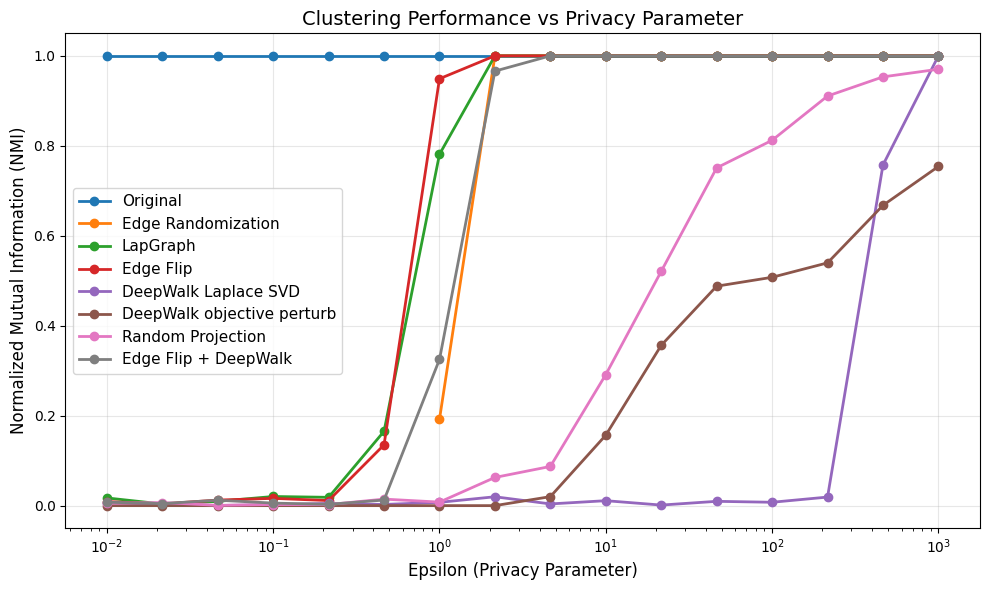

In [11]:
# Plot the results
plt.figure(figsize=(10, 6))
for method, nmi_scores in results.items():
    plt.plot(epsilon_values, nmi_scores, marker='o', label=method, linewidth=2, markersize=6)

plt.xlabel('Epsilon (Privacy Parameter)', fontsize=12)
plt.ylabel('Normalized Mutual Information (NMI)', fontsize=12)
plt.title('Clustering Performance vs Privacy Parameter', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xscale('log')  # Log scale for better visualization of epsilon values
plt.tight_layout()
plt.show()

## Polblogs

In [8]:
### complete this to process the blog data here..
data_path =  "./datasets/polblogs/polblogs.gml"
G = nx.read_gml(data_path)
G = nx.Graph(G) ## convert from multigraph to regular
G = G.to_undirected()
largest_cc = max(nx.connected_components(G), key=len)
G = G.subgraph(largest_cc)
## need to figure this out here...
a = G.nodes.data()
true_labels = [data["value"] for _, data in a]

A = nx.to_numpy_array(G)

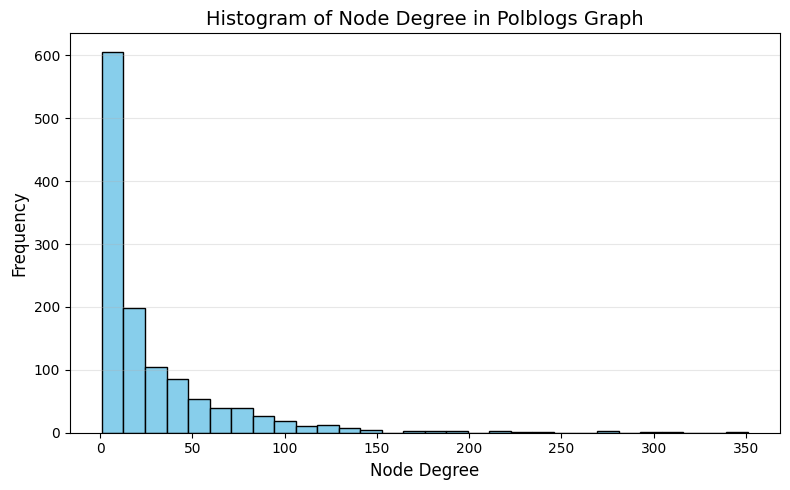

In [40]:
# Degree histogram
degrees = [d for n, d in G.degree]
plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Node Degree', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Node Degree in Polblogs Graph', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

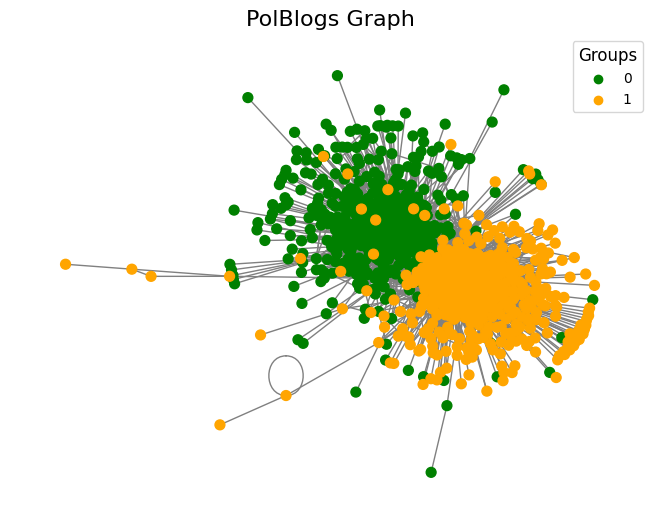

In [131]:
# Plot out network
cluster_labels = true_labels
color_map = {
    0: 'green', 
    1: 'orange',
}
node_colors = [color_map[label] for label in cluster_labels]
nx.draw(
    G, 
    with_labels=False,
    node_color=node_colors,
    edge_color='gray',
    node_size=50,
    pos=nx.spring_layout(G, seed=1)
)
plt.title("PolBlogs Graph", fontsize=16)

for cluster, color in color_map.items():
    plt.scatter([], [], c=color, label=cluster)
plt.legend(title="Groups", fontsize=10, title_fontsize=12)
plt.show()

### comparing DP methods - no replication

In [136]:
# Run the experiments, average over the randomness of the dp mechanisms and clustering algorithms
torch.manual_seed(0)
np.random.seed(0)

# Define epsilon values to test
epsilon_values = np.logspace(-1, 3, num=12) 

sample_size = 1  # Number of runs for each method and epsilon
n_clusters_sc = 3
n_clusters_dw = 2
deepwalk_dimension=64
walk_length = 5

# Initialize results storage for boxplots: each method will have a list of lists (outer: epsilon, inner: sample_size runs)
results = {
    'Original': [],
    'Edge Randomization': [],
    'LapGraph': [],
    'Edge Flip': [],
    'DeepWalk Laplace SVD': [],
    'DeepWalk objective perturb': [0,0,0,0,0.0014787406757714703, 0.0017219523922026808, 0.2073581375583297, 0.4358466068678115,0.5443441765112625, 0.6230440227723472, 0.6646150157147207,  0.6707341917725279 ],
    'Random Projection': [],
    'LapGraph + DeepWalk': [],
    'Edge Flip + DeepWalk': []
}
for idx, epsilon in enumerate(epsilon_values):
    print(f"Testing epsilon = {epsilon}")
    for run in range(sample_size):
        # Original matrix (no perturbation)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters_sc, affinity='precomputed', random_state=run)
        cluster_labels = spectral_clustering.fit_predict(A)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Original'].append(nmi_score)
        
        # Random Projection
        A_rp = random_projection(A, 100, epsilon=epsilon, delta=0.01)
        kmeans = KMeans(n_clusters=n_clusters_sc, n_init=10, random_state=run)
        cluster_labels = kmeans.fit_predict(A_rp)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Random Projection'].append(nmi_score)

        # Edge Randomization
        if epsilon >= np.log(2):
            A_er = edge_randomization(A, epsilon)
            spectral_clustering = SpectralClustering(n_clusters=n_clusters_sc, affinity='precomputed', random_state=run)
            cluster_labels = spectral_clustering.fit_predict(A_er)
            nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
            results['Edge Randomization'].append(nmi_score)
        else:
            results['Edge Randomization'].append(None)
        
        # LapGraph
        A_lg = lapgraph(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters_sc, affinity='precomputed', random_state=run)
        cluster_labels = spectral_clustering.fit_predict(A_lg)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['LapGraph'].append(nmi_score)
        
        # # Edge Flip
        A_ef = edge_flip(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters_sc, affinity='precomputed', random_state=run)
        cluster_labels = spectral_clustering.fit_predict(A_ef)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip'].append(nmi_score)

        # DeepWalk Laplace SVD
        X = deepwalk_laplace_svd(A, deepwalk_dimension, walk_length=walk_length, epsilon=epsilon, take_log=False)
        X = X.detach().numpy()
        kmeans = KMeans(n_clusters=n_clusters_dw, n_init=10, random_state=run)
        cluster_labels = kmeans.fit_predict(X)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['DeepWalk Laplace SVD'].append(nmi_score)

        # LapGraph + Deep Walk
        G_test = nx.from_numpy_array(A_lg)
        X = deepwalk_get_H(G_test, deepwalk_dimension, window=walk_length, seed=run)
        kmeans = KMeans(n_clusters=n_clusters_dw, n_init=10, random_state=run)
        cluster_labels = kmeans.fit_predict(X)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['LapGraph + DeepWalk'].append(nmi_score)

        # Edge Flip + Deep Walk
        G_test = nx.from_numpy_array(A_ef)
        X = deepwalk_get_H(G_test, deepwalk_dimension, window=walk_length, seed=run)
        kmeans = KMeans(n_clusters=n_clusters_dw, n_init=10, random_state=run)
        cluster_labels = kmeans.fit_predict(X)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + DeepWalk'].append(nmi_score)

Testing epsilon = 0.1


Computing transition probabilities:   0%|          | 0/1222 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:04<00:00,  2.15it/s]


Computing transition probabilities:   0%|          | 0/1222 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:45<00:00,  4.58s/it]


...

/tmp/ipykernel_7936/2661552418.py:12: RuntimeWarning: overflow encountered in exp
  s = 2/np.exp(epsilon)
/tmp/ipykernel_7936/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


Computing transition probabilities:   0%|          | 0/1222 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:08<00:00,  1.15it/s]


Computing transition probabilities:   0%|          | 0/1222 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:08<00:00,  1.16it/s]


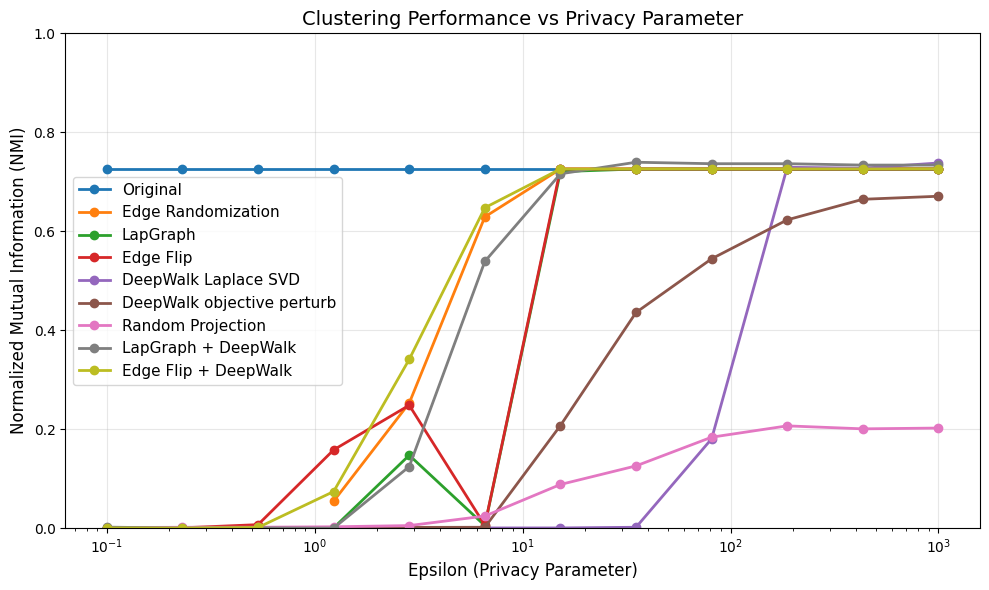

In [137]:
# Plot the results
plt.figure(figsize=(10, 6))
for method, nmi_scores in results.items():
    plt.plot(epsilon_values, nmi_scores, marker='o', label=method, linewidth=2, markersize=6)

plt.xlabel('Epsilon (Privacy Parameter)', fontsize=12)
plt.ylabel('Normalized Mutual Information (NMI)', fontsize=12)
plt.title('Clustering Performance vs Privacy Parameter', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0,1)
plt.xscale('log')  # Log scale for better visualization of epsilon values
plt.tight_layout()
plt.show()

In [143]:
#save output
import os
import json


def convert_to_json_serializable(obj):
    # Recursively convert numpy types to native Python types
    if isinstance(obj, dict):
        return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_json_serializable(v) for v in obj]
    elif hasattr(obj, "tolist"):
        return obj.tolist()
    elif obj is None:
        return None
    else:
        return obj

os.makedirs("logs", exist_ok=True)
with open("logs/ours/all_methods_1_replication.json", "w") as f:
    json.dump(convert_to_json_serializable(results), f)

### comparing DP methods - 10 replications - 3 clusters

In [79]:
# Run the experiments, average over the randomness of the dp mechanisms and clustering algorithms
torch.manual_seed(0)
np.random.seed(0)

# Define epsilon values to test
epsilon_values = np.logspace(-1, 3, num=12) 

sample_size = 10  # Number of runs for each method and epsilon
n_clusters = 3
deepwalk_dimension=64
walk_length = 5

# Initialize results storage for boxplots: each method will have a list of lists (outer: epsilon, inner: sample_size runs)
results = {
    'Original': [[] for _ in range(len(epsilon_values))],
    'Edge Randomization': [[] for _ in range(len(epsilon_values))],
    'LapGraph': [[] for _ in range(len(epsilon_values))],
    'Edge Flip': [[] for _ in range(len(epsilon_values))],
    'DeepWalk Laplace SVD': [[] for _ in range(len(epsilon_values))],
    'Random Projection': [[] for _ in range(len(epsilon_values))],
    'LapGraph + DeepWalk': [[] for _ in range(len(epsilon_values))]
}
for idx, epsilon in enumerate(epsilon_values):
    print(f"Testing epsilon = {epsilon}")
    for run in range(sample_size):
        # Original matrix (no perturbation)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=run)
        cluster_labels = spectral_clustering.fit_predict(A)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Original'][idx].append(nmi_score)
        
        # Random Projection
        A_rp = random_projection(A, 100, epsilon=epsilon, delta=0.01)
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=run)
        cluster_labels = kmeans.fit_predict(A_rp)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Random Projection'][idx].append(nmi_score)

        # Edge Randomization
        if epsilon >= np.log(2):
            A_er = edge_randomization(A, epsilon)
            spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=run)
            cluster_labels = spectral_clustering.fit_predict(A_er)
            nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
            results['Edge Randomization'][idx].append(nmi_score)
        else:
            results['Edge Randomization'][idx].append(None)
        
        # LapGraph
        A_lg = lapgraph(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=run)
        cluster_labels = spectral_clustering.fit_predict(A_lg)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['LapGraph'][idx].append(nmi_score)
        
        # # Edge Flip
        A_ef = edge_flip(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=run)
        cluster_labels = spectral_clustering.fit_predict(A_ef)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip'][idx].append(nmi_score)

        # DeepWalk Laplace SVD
        X = deepwalk_laplace_svd(A, deepwalk_dimension, walk_length=walk_length, epsilon=epsilon, take_log=False)
        X = X.detach().numpy()
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=run)
        cluster_labels = kmeans.fit_predict(X)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['DeepWalk Laplace SVD'][idx].append(nmi_score)

        # LapGraph + Deep Walk
        G_test = nx.from_numpy_array(A_lg)
        X = deepwalk_get_H(G_test, deepwalk_dimension, window=walk_length, seed=run)
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=run)
        cluster_labels = kmeans.fit_predict(X)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['LapGraph + DeepWalk'][idx].append(nmi_score)



Testing epsilon = 0.1


Computing transition probabilities:   0%|          | 0/1222 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:04<00:00,  2.01it/s]


Computing transition probabilities:   0%|          | 0/1222 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:05<00:00,  1.82it/s]


...

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:08<00:00,  1.15it/s]
/tmp/ipykernel_7936/2661552418.py:12: RuntimeWarning: overflow encountered in exp
  s = 2/np.exp(epsilon)
/tmp/ipykernel_7936/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


Computing transition probabilities:   0%|          | 0/1222 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:08<00:00,  1.19it/s]
/tmp/ipykernel_7936/2661552418.py:12: RuntimeWarning: overflow encountered in exp
  s = 2/np.exp(epsilon)
/tmp/ipykernel_7936/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


Computing transition probabilities:   0%|          | 0/1222 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:08<00:00,  1.15it/s]


In [80]:
#save output
import os
import json


def convert_to_json_serializable(obj):
    # Recursively convert numpy types to native Python types
    if isinstance(obj, dict):
        return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_json_serializable(v) for v in obj]
    elif hasattr(obj, "tolist"):
        return obj.tolist()
    elif obj is None:
        return None
    else:
        return obj

os.makedirs("logs", exist_ok=True)
with open("logs/ours/3_clusters_final.json", "w") as f:
    json.dump(convert_to_json_serializable(results), f)



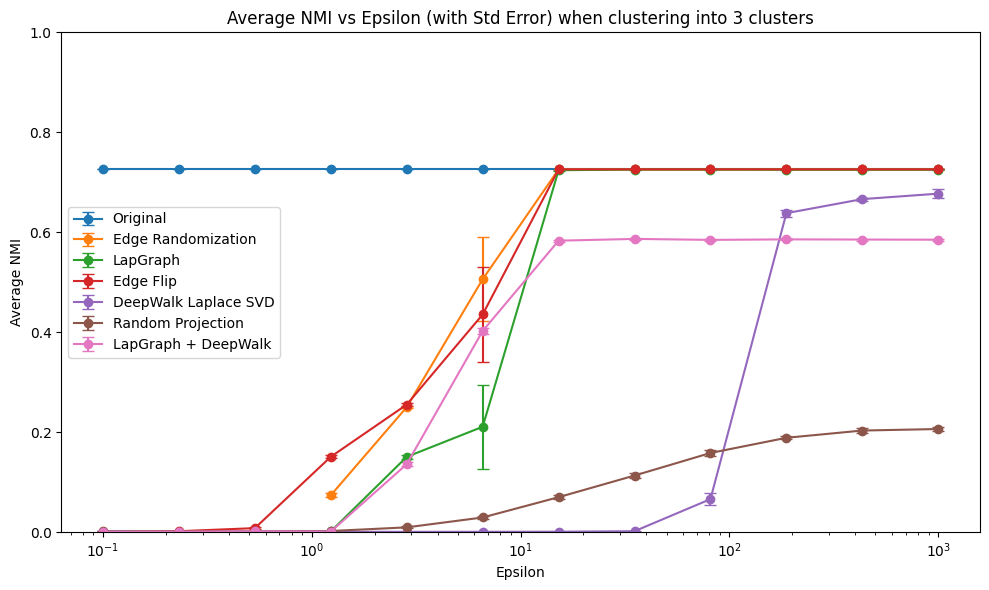

In [81]:
# Compute mean and std for each method at each epsilon
method_means = {}
method_stds = {}
for method in results:
    means = []
    stds = []
    for j, eps in enumerate(epsilon_values):
        nmi_scores = [v for v in results[method][j] if v is not None]
        if len(nmi_scores) > 0:
            means.append(np.mean(nmi_scores))
            stds.append(np.std(nmi_scores, ddof=1)/np.sqrt(sample_size))
        else:
            means.append(np.nan)
            stds.append(np.nan)
    method_means[method] = means
    method_stds[method] = stds

# Plot
plt.figure(figsize=(10, 6))
for i, method in enumerate(results.keys()):
    means = method_means[method]
    stds = method_stds[method]
    plt.errorbar(
        [float(e) for e in epsilon_values], 
        means, 
        yerr=stds, 
        label=method, 
        marker='o', 
        capsize=4, 
        linestyle='-'
    )

plt.xscale('log')
plt.ylim(0,1)
plt.xlabel('Epsilon')
plt.ylabel('Average NMI')
plt.title('Average NMI vs Epsilon (with Std Error) when clustering into 3 clusters')
plt.legend()
plt.tight_layout()
plt.show()


### comparing DP methods - 10 replications - 2 clusters

In [82]:
# Run the experiments, average over the randomness of the dp mechanisms and clustering algorithms
torch.manual_seed(0)
np.random.seed(0)

# Define epsilon values to test
epsilon_values = np.logspace(-1, 3, num=12) 

sample_size = 10  # Number of runs for each method and epsilon
n_clusters = 2
deepwalk_dimension=64
walk_length = 5

# Initialize results storage for boxplots: each method will have a list of lists (outer: epsilon, inner: sample_size runs)
results = {
    'Original': [[] for _ in range(len(epsilon_values))],
    'Edge Randomization': [[] for _ in range(len(epsilon_values))],
    'LapGraph': [[] for _ in range(len(epsilon_values))],
    'Edge Flip': [[] for _ in range(len(epsilon_values))],
    'DeepWalk Laplace SVD': [[] for _ in range(len(epsilon_values))],
    'Random Projection': [[] for _ in range(len(epsilon_values))],
    'LapGraph + DeepWalk': [[] for _ in range(len(epsilon_values))]
}
for idx, epsilon in enumerate(epsilon_values):
    print(f"Testing epsilon = {epsilon}")
    for run in range(sample_size):
        # Original matrix (no perturbation)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=run)
        cluster_labels = spectral_clustering.fit_predict(A)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Original'][idx].append(nmi_score)
        
        # Random Projection
        A_rp = random_projection(A, 100, epsilon=epsilon, delta=0.01)
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=run)
        cluster_labels = kmeans.fit_predict(A_rp)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Random Projection'][idx].append(nmi_score)

        # Edge Randomization
        if epsilon >= np.log(2):
            A_er = edge_randomization(A, epsilon)
            spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=run)
            cluster_labels = spectral_clustering.fit_predict(A_er)
            nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
            results['Edge Randomization'][idx].append(nmi_score)
        else:
            results['Edge Randomization'][idx].append(None)
        
        # LapGraph
        A_lg = lapgraph(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=run)
        cluster_labels = spectral_clustering.fit_predict(A_lg)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['LapGraph'][idx].append(nmi_score)
        
        # # Edge Flip
        A_ef = edge_flip(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=run)
        cluster_labels = spectral_clustering.fit_predict(A_ef)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip'][idx].append(nmi_score)

        # DeepWalk Laplace SVD
        X = deepwalk_laplace_svd(A, deepwalk_dimension, walk_length=walk_length, epsilon=epsilon, take_log=False)
        X = X.detach().numpy()
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=run)
        cluster_labels = kmeans.fit_predict(X)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['DeepWalk Laplace SVD'][idx].append(nmi_score)

        # LapGraph + Deep Walk
        G_test = nx.from_numpy_array(A_lg)
        X = deepwalk_get_H(G_test, deepwalk_dimension, window=walk_length, seed=run)
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=run)
        cluster_labels = kmeans.fit_predict(X)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['LapGraph + DeepWalk'][idx].append(nmi_score)

Testing epsilon = 0.1


Computing transition probabilities:   0%|          | 0/1222 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:04<00:00,  2.28it/s]


Computing transition probabilities:   0%|          | 0/1222 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:04<00:00,  2.16it/s]


...

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:08<00:00,  1.16it/s]
/tmp/ipykernel_7936/2661552418.py:12: RuntimeWarning: overflow encountered in exp
  s = 2/np.exp(epsilon)
/tmp/ipykernel_7936/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


Computing transition probabilities:   0%|          | 0/1222 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:08<00:00,  1.18it/s]
/tmp/ipykernel_7936/2661552418.py:12: RuntimeWarning: overflow encountered in exp
  s = 2/np.exp(epsilon)
/tmp/ipykernel_7936/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


Computing transition probabilities:   0%|          | 0/1222 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:08<00:00,  1.17it/s]


In [83]:
#save output
import os
import json


def convert_to_json_serializable(obj):
    # Recursively convert numpy types to native Python types
    if isinstance(obj, dict):
        return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_json_serializable(v) for v in obj]
    elif hasattr(obj, "tolist"):
        return obj.tolist()
    elif obj is None:
        return None
    else:
        return obj

os.makedirs("logs", exist_ok=True)
with open("logs/ours/2_clusters_final.json", "w") as f:
    json.dump(convert_to_json_serializable(results), f)

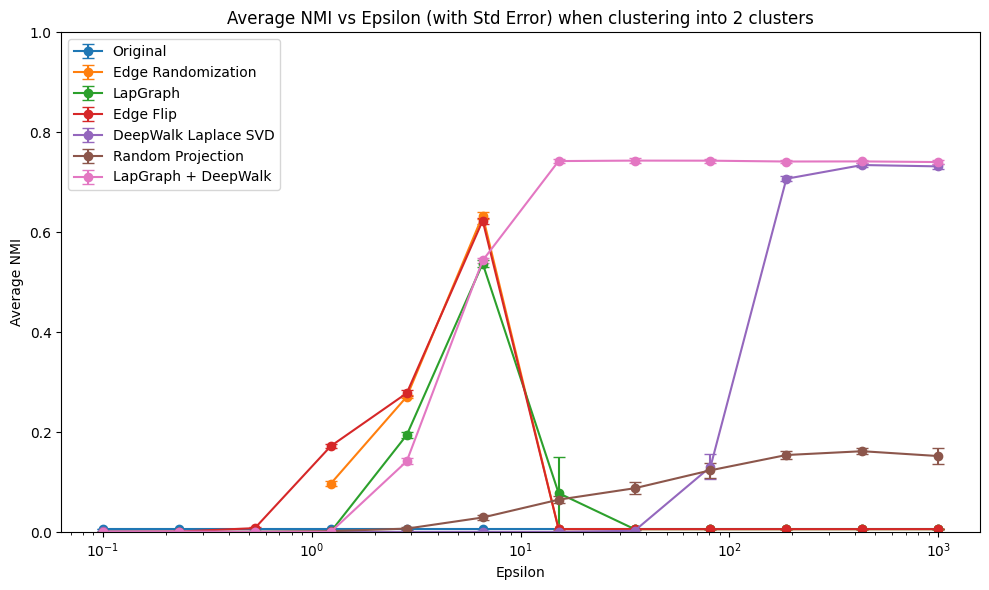

In [84]:
# Compute mean and std for each method at each epsilon
method_means = {}
method_stds = {}
for method in results:
    means = []
    stds = []
    for j, eps in enumerate(epsilon_values):
        nmi_scores = [v for v in results[method][j] if v is not None]
        if len(nmi_scores) > 0:
            means.append(np.mean(nmi_scores))
            stds.append(np.std(nmi_scores, ddof=1)/np.sqrt(sample_size))
        else:
            means.append(np.nan)
            stds.append(np.nan)
    method_means[method] = means
    method_stds[method] = stds

# Plot
plt.figure(figsize=(10, 6))
for i, method in enumerate(results.keys()):
    means = method_means[method]
    stds = method_stds[method]
    plt.errorbar(
        [float(e) for e in epsilon_values], 
        means, 
        yerr=stds, 
        label=method, 
        marker='o', 
        capsize=4, 
        linestyle='-'
    )

plt.xscale('log')
plt.ylim(0,1)
plt.xlabel('Epsilon')
plt.ylabel('Average NMI')
plt.title('Average NMI vs Epsilon (with Std Error) when clustering into 2 clusters')
plt.legend()
plt.tight_layout()
plt.show()